# Exploring Auto-Annotation with Expert-Crafted Guidelines through 3D LiDAR Detection

This Jupyter Notebook runs our AutoExpert for 3D LiDAR Detection on one sequence. It displays visual results overlaid on images and BEV view of LiDAR point clouds.

## Cell 0: Save 2D Detections by the Finetuned GroundingDINO (with Evaluation)

In [2]:
import sys
sys.path.append('./mmdetection')

import os
import os.path as osp
import warnings
from copy import deepcopy

from mmengine import ConfigDict
from mmengine.config import Config
from mmengine.runner import Runner

from mmdet.engine.hooks.utils import trigger_visualization_hook
from mmdet.evaluation import DumpDetResults
from mmdet.registry import RUNNERS
from mmdet.utils import setup_cache_size_limit_of_dynamo


import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

def main():

    config_file = 'mmdetection/configs/mm_grounding_dino/one_seq/grounding_dino_swin-l_finetune_8xb4_20e_nuscenes_test.py'
    checkpoint = 'weights/GD.pth'
    work_dir = None
    out_file = None
    show = False
    show_dir = None
    wait_time = 2.0
    cfg_options = None
    launcher = 'none'
    tta = False
    local_rank = 0

    if 'LOCAL_RANK' not in os.environ:
        os.environ['LOCAL_RANK'] = str(local_rank)

    # Reduce the number of repeated compilations and improve testing speed.
    setup_cache_size_limit_of_dynamo()

    # load config
    cfg = Config.fromfile(config_file)
    cfg.launcher = launcher
    if cfg_options is not None:
        cfg.merge_from_dict(cfg_options)

    # work_dir is determined in this priority: CLI > segment in file > filename
    if work_dir is not None:
        # update configs according to CLI args if work_dir is not None
        cfg.work_dir = work_dir
    elif cfg.get('work_dir', None) is None:
        # use config filename as default work_dir if cfg.work_dir is None
        cfg.work_dir = osp.join('./work_dirs',
                                osp.splitext(osp.basename(config_file))[0])

    cfg.load_from = checkpoint

    visualization_config = ConfigDict(
        show=show,
        wait_time=wait_time,
        show_dir=show_dir
    )
    if show or show_dir:
        cfg = trigger_visualization_hook(cfg, visualization_config)

    if tta:
        if 'tta_model' not in cfg:
            warnings.warn('Cannot find ``tta_model`` in config, '
                          'we will set it as default.')
            cfg.tta_model = dict(
                type='DetTTAModel',
                tta_cfg=dict(
                    nms=dict(type='nms', iou_threshold=0.5), max_per_img=100))
        if 'tta_pipeline' not in cfg:
            warnings.warn('Cannot find ``tta_pipeline`` in config, '
                          'we will set it as default.')
            test_data_cfg = cfg.test_dataloader.dataset
            while 'dataset' in test_data_cfg:
                test_data_cfg = test_data_cfg['dataset']
            cfg.tta_pipeline = deepcopy(test_data_cfg.pipeline)
            flip_tta = dict(
                type='TestTimeAug',
                transforms=[
                    [
                        dict(type='RandomFlip', prob=1.),
                        dict(type='RandomFlip', prob=0.)
                    ],
                    [
                        dict(
                            type='PackDetInputs',
                            meta_keys=('img_id', 'img_path', 'ori_shape',
                                       'img_shape', 'scale_factor', 'flip',
                                       'flip_direction'))
                    ],
                ])
            cfg.tta_pipeline[-1] = flip_tta
        cfg.model = ConfigDict(**cfg.tta_model, module=cfg.model)
        cfg.test_dataloader.dataset.pipeline = cfg.tta_pipeline

    # build the runner from config
    if 'runner_type' not in cfg:
        # build the default runner
        runner = Runner.from_cfg(cfg)
    else:
        # build customized runner from the registry
        # if 'runner_type' is set in the cfg
        runner = RUNNERS.build(cfg)

    # add `DumpResults` dummy metric
    if out_file is not None:
        assert out_file.endswith(('.pkl', '.pickle')), \
            'The dump file must be a pkl file.'
        runner.test_evaluator.metrics.append(
            DumpDetResults(out_file_path=out_file))

    # start testing
    runner.test()


if __name__ == '__main__':
    main()

11/21 09:09:44 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.8.20 (default, Oct  3 2024, 15:24:27) [GCC 11.2.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 188839258
    GPU 0,1: NVIDIA RTX A6000
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 11.4, V11.4.48
    GCC: gcc (Ubuntu 7.5.0-6ubuntu2) 7.5.0
    PyTorch: 2.4.1+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2021.4-Product Build 20210904 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.4.2 (Git Hash 1137e04ec0b5251ca2b4400a4fd3c667ce843d67)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-gencode;

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


11/21 09:09:46 - mmengine - INFO - Config:
auto_scale_lr = dict(base_batch_size=64, enable=False)
backend_args = None
class_name = (
    'car',
    'truck',
    'trailer',
    'container',
    'bus',
    'construction_vehicle',
    'bicycle bike',
    'narrow motorcycle',
    'police vehicle',
    'emergency vehicle',
    'adult',
    'single little short youth children',
    'law enforcement officer',
    'construction worker',
    'laborer',
    'stroller',
    'personal_mobility',
    'small kick scooter',
    'pushable pullable garbage container',
    'hand truck',
    'debris',
    'full trash bags',
    'traffic_cone',
    'barrier',
)
coco_od_dataset = dict(
    ann_file='o365v1_train_odvg.json',
    backend_args=None,
    data_prefix=dict(img='train/'),
    data_root='data/objects365v1/',
    filter_cfg=dict(filter_empty_gt=False),
    label_map_file='o365v1_label_map.json',
    pipeline=[
        dict(backend_args=None, type='LoadImageFromFile'),
        dict(type='LoadAnnotat

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Loads checkpoint by local backend from path: weights/GD.pth
11/21 09:09:56 - mmengine - INFO - Load checkpoint from weights/GD.pth


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

11/21 09:11:53 - mmengine - INFO - Evaluating bbox...
Loading and preparing results...
DONE (t=0.38s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.20s).
Accumulating evaluation results...
DONE (t=0.76s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.191
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=1000 ] = 0.456
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=1000 ] = 0.138
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.061
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = 0.176
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = 0.323
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.324
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=300 ] = 0.328
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=1000 ] = 0.328
 Average

## Cell 1: Generate 2D Masks with SAM

In [2]:
import json
import os

def main():

    r_path = 'data/nuscenes/outputs/result_2D_0_seq.bbox.json'
    output_path = 'data/nuscenes/outputs/result_2D_0_seq_0.1.bbox.json'
    annos_path = 'data/nuscenes/test_val_0_seq.json'
    score_thre = 0.1
    
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    with open(annos_path, "r") as f:
        annos = json.load(f)
    images_name_list = annos["images"]
    
    with open(r_path, 'r') as file:
        r = json.load(file)
    
    r_filter = []
    for index in range(len(r)):
        result = r[index]
        image_id = result['image_id']
        score = result['score']
        if score < score_thre:
            continue 
        for temp in images_name_list:
            if image_id == temp['id']:
                image_name = temp['file_name']
                break
        result['file_name'] = image_name
        r_filter.append(result)
    
    with open(output_path, 'w') as file:
        json.dump(r_filter, file)
    
    print(f"Filtering completed! Input: {len(r)} results, Output: {len(r_filter)} results (score >= {score_thre})")
    print(f"Results saved to: {output_path}")

if __name__ == "__main__":
    main()

Filtering completed! Input: 72000 results, Output: 10519 results (score >= 0.1)
Results saved to: data/nuscenes/outputs/result_2D_0_seq_0.1.bbox.json


In [7]:
import sys
sys.path.append('./src')
import json
import os
import cv2
import random
import time
import numpy as np
import torch
import torchvision
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.splits import mini_train, mini_val, train_detect, train, val
from PIL import Image, ImageDraw
from segment_anything import SamAutomaticMaskGenerator, SamPredictor, build_sam
from tqdm import tqdm
import pycocotools.mask
import pickle
from cfg.prompt_cfg import PROMPT_MAPS  

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

def draw_mask(mask, draw, random_color=False):
    if random_color:
        color = (
            random.randint(0, 255),
            random.randint(0, 255),
            random.randint(0, 255),
            153,
        )
    else:
        color = (30, 144, 255, 153)

    nonzero_coords = np.transpose(np.nonzero(mask))
    for coord in nonzero_coords:
        draw.point(coord[::-1], fill=color)

# utils
def count_frames(nusc, sample):
    frame_count = 1

    if sample["next"] != "":
        frame_count += 1

        sample_counter = nusc.get("sample", sample["next"])

        while sample_counter["next"] != "":
            frame_count += 1
            sample_counter = nusc.get("sample", sample_counter["next"])

    return frame_count

def map_class(name):
    if name in PROMPT_MAPS.keys():
        return PROMPT_MAPS[name]
    sys.exit()
    return False

if __name__ == "__main__":
    # Set default parameter values
    ver_name = "v1.0-trainval"
    data_path = "data/nuscenes/"
    sam_ckpt = "weights/sam_vit_h_4b8939.pth"
    output_dir = "outputs/nuscenes/results_mask/nuscenes-gd-sam/"
    gd_path = "data/nuscenes/outputs/result_2D_0_seq_0.1.bbox.json"

    print("[INFO] Running with parameters:")
    print(f"  ver_name: {ver_name}")
    print(f"  data_path: {data_path}")
    print(f"  sam_ckpt: {sam_ckpt}")
    print(f"  output_dir: {output_dir}")
    print(f"  gd_path: {gd_path}")

    custom_vocabulary = ['car', 'truck', 'trailer', 'bus', 'construction_vehicle', 'bicycle', 'motorcycle', 'emergency_vehicle',
                        'adult', 'child', 'police_officer', 'construction_worker', 'stroller', 'personal_mobility',
                        'pushable_pullable', 'debris', 'traffic_cone', 'barrier']              

    VER_NAME = ver_name
    DATA_PATH = data_path
    CAM_LIST = [
        "CAM_FRONT",
        "CAM_FRONT_RIGHT",
        "CAM_BACK_RIGHT",
        "CAM_BACK",
        "CAM_BACK_LEFT",
        "CAM_FRONT_LEFT",
    ]
    SAM_CKPT = sam_ckpt
    OUTPUT_DIR = output_dir
    GD_PATH = gd_path
    DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
    os.makedirs(output_dir, exist_ok=True)

    # Load GroundingDINO results
    with open(GD_PATH, "r") as f:
        results_GD = json.load(f)
    results_GD_new = dict()
    for result_GD in results_GD:
        file_name = result_GD['file_name']
        x1, y1, w, h = result_GD['bbox']
        x2, y2 = x1 + w, y1 + h    
        if file_name in results_GD_new:
            results_GD_new[file_name]['boxes_filt_list'].append([x1, y1, x2, y2])
            results_GD_new[file_name]['pred_phrases'].append(f"{custom_vocabulary[result_GD['category_id']-1]}({round(result_GD['score'], 2)})")
        else:
            results_GD_new[file_name] = dict()
            results_GD_new[file_name]['boxes_filt_list'] = list()
            results_GD_new[file_name]['pred_phrases'] = list()
            results_GD_new[file_name]['boxes_filt_list'].append([x1, y1, x2, y2])
            results_GD_new[file_name]['pred_phrases'].append(f"{custom_vocabulary[result_GD['category_id']-1]}({round(result_GD['score'], 2)})") 

    start_time = time.time()
    global blip_processor, blip_model, groundingdino_model, sam_predictor, sam_automask_generator, inpaint_pipeline

    # Initialize NuScenes dataset
    nusc = NuScenes(version=VER_NAME, dataroot=DATA_PATH, verbose=True)

    # Initialize SAM model
    assert SAM_CKPT, "sam_checkpoint is not found!"
    sam = build_sam(checkpoint=SAM_CKPT)
    sam.to(device=DEVICE)
    sam_predictor = SamPredictor(sam)
    sam_automask_generator = SamAutomaticMaskGenerator(sam)

    # Create output directory
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    sample_count = 1

    # Process each scene
    for scene_num, scene_name in enumerate(val):
        if scene_num > 0:
            break
        scene_token = nusc.field2token("scene", "name", scene_name)[0]
        scene = nusc.get("scene", scene_token)
        sample = nusc.get("sample", scene["first_sample_token"])

        num_frames = count_frames(nusc, sample)
        for f in tqdm(range(num_frames), desc=scene_name+": "):
            frame_start_time = time.time()
            cam_nums = []
            labels = []
            detection_scores = []
            im_to_ego_mats = []
            mask_images = []
            data = {}
            np_mask_images = []

            # Process each camera
            for c in range(len(CAM_LIST)):
                this_cam_labels = []
                this_cam_scores = []

                (path, nusc_boxes, camera_instrinsic) = nusc.get_sample_data(
                    sample["data"][CAM_LIST[c]]
                )

                # Use GD 2D results
                detic_start = time.time()
                file_name = path.split('/')[-1]
                if file_name in results_GD_new:
                    image_pil = Image.open(path).convert('RGB')
                    image = np.array(image_pil)
                    image = image[:, :, ::-1].copy()  
                    boxes_filt_list = results_GD_new[file_name]['boxes_filt_list']
                    pred_phrases = results_GD_new[file_name]['pred_phrases']                
                    boxes_filt = torch.tensor(boxes_filt_list).cuda()
                else:
                    print("\nNo box found in this image.\n")
                    im_to_ego_mats.append([])
                    continue
                    
                detic_end = time.time()

                # Prepare prediction dictionary for visualization
                size = image_pil.size
                pred_dict = {
                    "boxes": boxes_filt,
                    "size": [size[1], size[0]],  # H, W
                    "labels": pred_phrases,
                }
                np_image = np.array(image_pil)
                boxes_filt = boxes_filt.cpu()

                # Extract labels and scores
                nms_start = time.time()
                for i, (box, label) in enumerate(zip(boxes_filt, pred_phrases)):
                    idx = label.find("(")
                    ds = label[idx + 1 : -1]
                    label = label[:idx]

                    this_cam_labels.append(map_class(label.lower()))
                    this_cam_scores.append(float(ds))
            
                # Apply class-wise NMS
                run_nms = True
                if run_nms:
                    nms_scores = []
                    nms_boxes_filt = torch.Tensor([])
                    nms_labels = []

                    for cls in set(PROMPT_MAPS.values()):
                        cls_boxes = boxes_filt[[i for i, l in enumerate(this_cam_labels) if l == cls]]
                        cls_scores = [this_cam_scores[i] for i, l in enumerate(this_cam_labels) if l == cls]

                        if len(cls_boxes) == 0:
                            continue

                        keep = torchvision.ops.nms(cls_boxes, torch.Tensor(cls_scores), 0.75)
                        keep = keep.cpu()
                        cls_boxes = cls_boxes[keep]
                        cls_scores = [cls_scores[i] for i in keep]
                        cls_labels = [cls for _ in range(len(keep))]
                        nms_boxes_filt = torch.cat((nms_boxes_filt, cls_boxes), dim=0)
                        nms_scores.extend(cls_scores)
                        nms_labels.extend(cls_labels)

                    boxes_filt = nms_boxes_filt
                    detection_scores.extend(nms_scores)
                    labels.extend(nms_labels)

                else:
                    detection_scores.extend(this_cam_scores)
                    labels.extend(this_cam_labels)
                    nms_labels = this_cam_labels
                
                nms_end = time.time()
                    
                # Generate masks using SAM
                sam_start = time.time()
                sam_predictor.set_image(np_image)
                
                transformed_boxes = sam_predictor.transform.apply_boxes_torch(boxes_filt, image.shape[:2]).to(DEVICE)
                if transformed_boxes.shape[0] == 0:
                    print("No objects found.")
                    im_to_ego_mats.append([])
                    continue
                

                masks, _, _ = sam_predictor.predict_torch(
                    point_coords=None,
                    point_labels=None,
                    boxes=transformed_boxes,
                    multimask_output=False,
                )

                sam_end = time.time()

                assert len(boxes_filt) == len(nms_labels) == len(masks)

                # Process each mask
                for i, (box, label, mask) in enumerate(zip(boxes_filt, pred_phrases, masks)):
                    mask_image = Image.new("RGBA", size, color=(0, 0, 0, 0))
                    mask_draw = ImageDraw.Draw(mask_image)
                    draw_mask(mask[0].cpu().numpy(), mask_draw)
                    cam_nums.append(c)

                    np_mask_image = np.array(mask_image).astype(np.uint8).transpose([2, 1, 0])[3, :, :]
                    np_mask_image = np.squeeze(np_mask_image)

                    compressed_np_mask_image = pycocotools.mask.encode(np.asfortranarray(np_mask_image))
                    np_mask_images.append(compressed_np_mask_image)

            np_images = np_mask_images

            if len(labels) == 0:
                continue

            assert len(labels) == len(detection_scores)
            assert len(labels) == len(cam_nums)
            assert len(np_images) == len(labels)

            data["labels"] = labels
            data["detection_scores"] = detection_scores
            data["cam_nums"] = cam_nums
            

            # Save results
            os.makedirs(os.path.join(OUTPUT_DIR, scene_name), exist_ok=True)
            with open(os.path.join(OUTPUT_DIR, f"{scene_name}", f"{f}_data.json"), "w") as outfile:
                json.dump(data, outfile)

            pickle.dump(np_images, open(os.path.join(OUTPUT_DIR, f"{scene_name}", f"{f}_masks.pkl"), 'wb'))

            if sample['next'] != "":
                sample = nusc.get('sample', sample['next'])
                sample_count += 1
            frame_end_time = time.time()
            # print(f"Took {frame_end_time - frame_start_time} seconds for a sample.")
    end_time = time.time()
    # print(f"Took {end_time - start_time} seconds for {sample_count} samples.")

[INFO] Running with parameters:
  ver_name: v1.0-trainval
  data_path: data/nuscenes/
  sam_ckpt: weights/sam_vit_h_4b8939.pth
  output_dir: outputs/nuscenes/results_mask/nuscenes-gd-sam/
  gd_path: data/nuscenes/outputs/result_2D_0_seq_0.1.bbox.json
Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 51.306 seconds.
Reverse indexing ...
Done reverse indexing in 9.5 seconds.


scene-0003: 100%|██████████| 40/40 [06:15<00:00,  9.38s/it]


## Cell 2: Generate 3D Cuboids for 2D Masks

In [1]:
import sys
sys.path.append('./src')
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import copy
import multiprocessing as mp
import random
import json
import pickle
import math
import pycocotools.mask
from pyquaternion import Quaternion as Quaternion
from PIL import Image
from os.path import join
import sys
from shapely.geometry import Point, box
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import Box
from nuscenes.utils.data_classes import Quaternion as nQuaternion
from utils.pcd import LidarPointCloud, view_points
from nuscenes.nuscenes import NuScenes, NuScenesExplorer
from nuscenes.map_expansion.map_api import NuScenesMap
from nuscenes.utils.splits import mini_val, mini_train, train_detect, train, val
from scipy.spatial.transform import Rotation as R
from scipy.spatial import distance_matrix
import scipy
import time
import tqdm
import numba
from numba import cuda
import warnings
warnings.filterwarnings("ignore")

@cuda.jit
def center2corner_3d_gpu(xi, yi, zi, xyz, ri, vertices):
    # Calculate for each vertex
    for i in range(8):
        x = xyz[0, i]
        y = xyz[1, i]
        z = xyz[2, i]
        
        # Apply rotation matrix around z-axis
        cos_r = math.cos(ri)
        sin_r = math.sin(ri)
        
        # Rotated coordinates
        vertices[i, 0] = xi + x * cos_r - y * sin_r
        vertices[i, 1] = yi + x * sin_r + y * cos_r
        vertices[i, 2] = zi + z

@cuda.jit(device=True)
def check_point_num_in_box_fast_v2_gpu(obj_lidar_pts, temp_box):
    total_num = obj_lidar_pts.shape[0]
    if total_num == 0:
        return 0
    in_box_num = 0
    min_x = min(temp_box[:, 0])
    max_x = max(temp_box[:, 0])
    min_y = min(temp_box[:, 1])
    max_y = max(temp_box[:, 1])
    for k, pt in enumerate(obj_lidar_pts):
        if (pt[0] < min_x or pt[0]  > max_x or pt[1] < min_y or pt[1] > max_y):
            continue

        in_flag = False
        j = 3
        for i in range(4):
            if ((temp_box[i, 1] > pt[1]) != (temp_box[j, 1] > pt[1])) and (
                pt[0] < (temp_box[j, 0] - temp_box[i, 0]) * (pt[1] - temp_box[i, 1]) / 
                (temp_box[j, 1] - temp_box[i, 1]) + temp_box[i, 0]
            ):
                in_flag = not in_flag
            j = i
        if in_flag:
            in_box_num = in_box_num + 1 
    
    return in_box_num / total_num

@cuda.jit
def find_best_pts_ratio_box_gpu(obj_lidar_pts, xyz, num_xyz, min_max_values, candidate_boxes, in_box_ratios, yaw_array):
    idx = cuda.grid(1)

    num_xi, num_yi, num_zi, num_ri = num_xyz
    if idx < num_xi * num_yi * num_zi * num_ri:
        min_x, max_x, min_y, max_y, min_z, max_z = min_max_values    
        xi_idx = idx // (num_yi * num_zi * num_ri) % num_xi
        yi_idx = idx // (num_zi * num_ri) % num_yi
        zi_idx = idx // num_ri % num_zi
        ri_idx = int(idx % num_ri)

        xi = min_x + xi_idx * step_xi
        yi = min_y + yi_idx * step_yi
        zi = min_z + zi_idx * step_zi
        ri = yaw_array[ri_idx]
            
        temp_box = cuda.local.array((8, 3), dtype=numba.float32)          
        center2corner_3d_gpu(xi, yi, zi, xyz, ri, temp_box)
        in_box_ratio = check_point_num_in_box_fast_v2_gpu(obj_lidar_pts, temp_box)     
        
        in_box_ratios[idx] = in_box_ratio
        for i in range(8):
            for j in range(3):
                candidate_boxes[idx, i, j] = temp_box[i, j] 

@cuda.jit
def count_max_elements_kernel(d_ratio, d_max_ratio, counter):
    tid = cuda.grid(1)
    if tid < d_ratio.size and d_ratio[tid] == d_max_ratio:
        cuda.atomic.add(counter, 0, 1)

@cuda.jit
def find_all_max_and_indices_kernel(d_ratio, d_max_ratio, indices):
    tid = cuda.grid(1)
    if tid < d_ratio.size and d_ratio[tid] == d_max_ratio:
        idx = cuda.atomic.add(indices, 0, 1) 
        indices[idx + 1] = tid

def find_best_pts_ratio_box_m(obj_lidar_pts, center, box_size, yaw_list):
    # Precompute min/max values on host
    min_x = center[0] - box_size[1]/2
    max_x = center[0] + box_size[1]/2
    min_y = center[1] - box_size[1]/2
    max_y = center[1] + box_size[1]/2
    min_z = center[2] - 1
    max_z = center[2] + 1

    num_xi = int((max_x - min_x) / step_xi) + 1
    num_yi = int((max_y - min_y) / step_yi) + 1
    num_zi = int((max_z - min_z) / step_zi) + 1
    num_ri = 2
    num_xyz = np.array([num_xi, num_yi, num_zi, num_ri], dtype=np.float32)

    w, l, h = box_size[0], box_size[1], box_size[2]
    x_list = [-l/2,-l/2,l/2,l/2,-l/2,-l/2,l/2,l/2]
    y_list = [w/2,-w/2,-w/2,w/2,w/2,-w/2,-w/2,w/2]
    z_list = [-h/2,-h/2,-h/2,-h/2,h/2,h/2,h/2,h/2]
    xyz = np.array([x_list, y_list, z_list], dtype=np.float32)

    # Pre-allocate candidate boxes buffer
    total_combinations = num_xi * num_yi * num_zi * num_ri
    max_candidate_boxes = total_combinations
    candidate_boxes = np.zeros((max_candidate_boxes, 8, 3), dtype=np.float32)

    # Copy data to GPU
    d_obj_lidar_pts = cuda.to_device(obj_lidar_pts[:, :3].astype(np.float32))  # Only need first 3 columns
    d_candidate_boxes = cuda.to_device(candidate_boxes)
    d_ratios = cuda.to_device(np.zeros(total_combinations, dtype=np.float32)) 
    d_yaw_array = cuda.to_device(np.array(yaw_list, dtype=np.float32))
    d_xyz = cuda.to_device(np.array(xyz, dtype=np.float32))

    threads_per_block = 256
    blocks_per_grid = (total_combinations + threads_per_block - 1) // threads_per_block
    find_best_pts_ratio_box_gpu[blocks_per_grid, threads_per_block](
        d_obj_lidar_pts,
        d_xyz,
        num_xyz,
        np.array([min_x, max_x, min_y, max_y, min_z, max_z], dtype=np.float32),
        d_candidate_boxes,
        d_ratios,
        d_yaw_array
    )

    counter = np.zeros(1, dtype=np.int32)
    d_max_ratio = max(d_ratios.copy_to_host())
    count_max_elements_kernel[blocks_per_grid, threads_per_block](d_ratios, d_max_ratio, counter)
    num_matches = counter[0]

    indices = np.zeros(num_matches + 1, dtype=np.int32)
    find_all_max_and_indices_kernel[blocks_per_grid, threads_per_block](d_ratios, d_max_ratio, indices)
    candidate_boxes = d_candidate_boxes.copy_to_host()[indices[1:]] 
    return candidate_boxes, d_max_ratio

def box_properties(points):
    center = np.mean(points, axis=0)
    
    length = np.linalg.norm(points[0] - points[2])
    width = np.linalg.norm(points[0] - points[1])
    height = np.linalg.norm(points[0] - points[4])

    v = points[1] - points[0]
    yaw = np.arctan2(v[1], v[0]) + np.pi / 2
    
    return center[0], center[1], center[2], width, length, height, yaw

@numba.jit(nopython=True)
def compute_iou(rec1, rec2):
    rec1 = (rec1[1], rec1[0], rec1[3], rec1[2])
    rec2 = (rec2[1], rec2[0], rec2[3], rec2[2])        
    """
    computing IoU
    :param rec1: (y0, x0, y1, x1), which reflects
            (top, left, bottom, right)
    :param rec2: (y0, x0, y1, x1)
    :return: scala value of IoU
    """
    # computing area of each rectangles
    S_rec1 = (rec1[2] - rec1[0]) * (rec1[3] - rec1[1])
    S_rec2 = (rec2[2] - rec2[0]) * (rec2[3] - rec2[1])
    
    # computing the sum_area
    sum_area = S_rec1 + S_rec2
    
    # find the each edge of intersect rectangle
    left_line = max(rec1[1], rec2[1])
    right_line = min(rec1[3], rec2[3])
    top_line = max(rec1[0], rec2[0])
    bottom_line = min(rec1[2], rec2[2])
    
    # judge if there is an intersect
    if left_line >= right_line or top_line >= bottom_line:
        return 0
    else:
        intersect = (right_line - left_line) * (bottom_line - top_line)
    return (intersect / (sum_area - intersect)) * 1.0 

@numba.jit(nopython=True)
def concatenate_columns(a, b):
    # Ensure input arrays a and b have the same number of rows
    if a.shape[0] != b.shape[0]:
        raise ValueError("Both arrays must have the same number of rows.")
    
    # Create a new array to store the result, with columns being the sum of a and b's columns
    result = np.empty((a.shape[0], a.shape[1] + b.shape[1]), dtype=a.dtype)
    
    # Copy a to the front of result
    for i in range(a.shape[0]):
        for j in range(a.shape[1]):
            result[i, j] = a[i, j]
            
    # Copy b to the back of result
    for i in range(b.shape[0]):
        for j in range(b.shape[1]):
            result[i, a.shape[1] + j] = b[i, j]
    
    return result

@numba.jit(nopython=True)
def world2img(points_world, pose_rec_translation, pose_rec_rotation_matrix, 
              cs_rec_translation, cs_rec_rotation_matrix, cam_intrinsic):
    points_world_homogeneous = concatenate_columns(points_world, np.ones((points_world.shape[0], 1), dtype=points_world.dtype))
    lidar2world = np.eye(4, dtype=points_world.dtype)
    lidar2world[:3, :3] = pose_rec_rotation_matrix
    lidar2world[:3, 3] = pose_rec_translation
    world2lidar = np.linalg.inv(lidar2world)
    points_lidar_homogeneous = points_world_homogeneous @ world2lidar.T
    points_lidar = points_lidar_homogeneous[:, :3] 

    camera2lidar = np.eye(4, dtype=points_lidar.dtype)
    camera2lidar[:3, :3] = cs_rec_rotation_matrix
    camera2lidar[:3, 3] = cs_rec_translation

    lidar2camera = np.linalg.inv(camera2lidar)
    points_camera_homogeneous = points_lidar_homogeneous @ lidar2camera.T
    points_camera = points_camera_homogeneous[:, :3]  
        
    valid = np.ones((points_camera.shape[0]), dtype=np.bool_)
    valid = np.logical_and(points_camera[:, -1] > 0.5, valid)

    points_camera = points_camera / points_camera[:, 2:3]
    camera2img = cam_intrinsic.astype(np.float32)
    points_img = points_camera @ camera2img.T
    points_img = points_img[:, :2]
    return points_img, valid

@numba.jit(nopython=True)
def check_point_in_img(points, height, width):
    valid = np.logical_and(points[:, 0] >= 0, points[:, 1] >= 0)
    valid = np.logical_and(valid,
                           np.logical_and(points[:, 0] < width,
                                          points[:, 1] < height))
    return valid

@numba.jit(nopython=True)
def check_2d_iou(box_3d, pose_rec_translation, pose_rec_rotation_matrix, 
                 cs_rec_translation, cs_rec_rotation_matrix, cam_intrinsic, pred_box):
    h, w = 900, 1600
    '''Project 3d prediction Box to image plane getting 2D gt Box'''
    corners_img_temp_box, valid_z_temp_box = world2img(box_3d, pose_rec_translation, pose_rec_rotation_matrix, 
                                                       cs_rec_translation, cs_rec_rotation_matrix, cam_intrinsic)
    valid_shape_temp_box = check_point_in_img(corners_img_temp_box, h, w)
    valid_all_temp_box = np.logical_and(valid_z_temp_box, valid_shape_temp_box)
    valid_shape_temp_box = valid_shape_temp_box.reshape(-1, 8)
    valid_all_temp_box = valid_all_temp_box.reshape(-1, 8)

    if valid_z_temp_box.sum() >= 1:
        min_col = max(min(corners_img_temp_box[valid_z_temp_box, 0].min(), w), 0)
        max_col = max(min(corners_img_temp_box[valid_z_temp_box, 0].max(), w), 0)
        min_row = max(min(corners_img_temp_box[valid_z_temp_box, 1].min(), h), 0)
        max_row = max(min(corners_img_temp_box[valid_z_temp_box, 1].max(), h), 0)        
        if (max_col - min_col) == 0 or (max_row - min_row) == 0:
            return -1            
    
        temp_box_2D = [int(min_col), int(min_row), int(max_col), int(max_row)]
        iou = compute_iou(temp_box_2D, pred_box)
        return iou
    return -1  

@numba.jit(nopython=True)
def find_best_box(candidate_boxes, pose_rec_translation, pose_rec_rotation_matrix, 
                  cs_rec_translation, cs_rec_rotation_matrix, cam_intrinsic, input_boxes):
    iou_thresh = 0
    max_iou = -1
    for box_2d in input_boxes:
        for box_3d in candidate_boxes:
            iou = check_2d_iou(box_3d, pose_rec_translation, pose_rec_rotation_matrix, 
                               cs_rec_translation, cs_rec_rotation_matrix, cam_intrinsic, box_2d)
            if iou > iou_thresh:
                if iou > max_iou:
                    max_iou = iou
                    best_box = box_3d
    return best_box

def hierarchical_occupancy_score(points, box, parts=[7,5,3]):
    all_confi = 0
    for part in parts:
        all_confi += compute_confidence(points, box, part)
    return all_confi/len(parts)

def compute_confidence(points, box, parts=6):
    x, y, z, w, l, h, yaw = box[0], box[1], box[2], box[3], box[4], box[5], box[6]

    cloud = np.zeros(shape=(points.shape[0], 4))
    cloud[:, 0:3] = points[:, 0:3]
    cloud[:, 3] = 1

    trans_mat = np.eye(4, dtype=np.float32)
    trans_mat[0, 0] = np.cos(yaw)
    trans_mat[0, 1] = -np.sin(yaw)
    trans_mat[0, 3] = x
    trans_mat[1, 0] = np.sin(yaw)
    trans_mat[1, 1] = np.cos(yaw)
    trans_mat[1, 3] = y
    trans_mat[2, 3] = z

    trans_mat_i = np.linalg.inv(trans_mat)
    cloud = np.matmul(cloud, trans_mat_i.T)

    delta_l = l/parts
    delta_w = w/parts

    valid_vol = 0

    for i in range(parts):
        for j in range(parts):
            mask_x_l = -l/2+i*delta_l<=cloud[:, 0]
            mask_x_r = cloud[:,0]<-l/2+(i+1)*delta_l
            mask_y_l = -w/2+j*delta_w<=cloud[:, 1]
            mask_y_r = cloud[:, 1]<-w/2+(j+1)*delta_w

            mask = mask_x_l*mask_x_r*mask_y_l*mask_y_r

            this_pts = cloud[mask]

            if len(this_pts)>1:
                valid_vol+=1

    return valid_vol/(parts**2)

# utils
def count_frames(nusc, sample):
    frame_count = 1

    if sample["next"] != "":
        frame_count += 1

        # Don't want to change where sample['next'] points to since it's used later, so we'll create our own pointer
        sample_counter = nusc.get('sample', sample['next'])

        while sample_counter['next'] != '':
            frame_count += 1
            sample_counter = nusc.get('sample', sample_counter['next'])
    
    return frame_count

def get_medoid(points):
    dist_matrix = torch.cdist(points.T, points.T, p=2)

    return torch.argmin(dist_matrix.sum(axis=0))


def get_detection_name(name):
    if name not in ["trafficcone", "constructionvehicle", "human"]:
        detection_name = name
    elif name == "trafficcone":
        detection_name = "traffic_cone"
    elif name == "constructionvehicle":
        detection_name = "construction_vehicle"
    elif name == "human":
        detection_name = "pedestrian"
    
    return detection_name

def push_centroid(centroid, extents, rot_quaternion, poserecord):
    centroid = np.squeeze(centroid)
    av_centroid = poserecord["translation"]
    ego_centroid = centroid - av_centroid

    l = extents[0]
    w = extents[1]

    
    angle = R.from_quat(list(rot_quaternion)).as_euler('xyz', degrees=False)

    theta = -angle[0]

    if np.isnan(theta):
        theta = 0.5 * np.pi
    
    alpha = np.arctan(np.abs(ego_centroid[1]) / np.abs(ego_centroid[0]))

    if ego_centroid[0] < 0:
        if ego_centroid[1] < 0:
            alpha = -np.pi + alpha
        else:
            alpha = np.pi - alpha
    else:
        if ego_centroid[1] < 0:
            alpha = -alpha

    offset = np.min( [np.abs(w / (2*np.sin(theta - alpha))), np.abs(l / (2*np.cos(theta - alpha)))] )

    x_dash = centroid[0] + offset * np.cos(alpha)
    y_dash = centroid[1] + offset * np.sin(alpha)

    pushed_centroid = np.array([x_dash, y_dash, centroid[2]])

    return pushed_centroid

def get_nusc_map(nusc, scene):
    # Get scene location
    log = nusc.get("log", scene["log_token"])
    location = log["location"]

    # Get nusc map
    nusc_map = NuScenesMap(dataroot=INPUT_PATH, map_name=location)

    return nusc_map

def get_all_lane_points_in_scene(nusc_map):
    lane_records = nusc_map.lane + nusc_map.lane_connector

    lane_tokens = [lane["token"] for lane in lane_records]

    lane_pt_dict = nusc_map.discretize_lanes(lane_tokens, 0.5)

    all_lane_pts = []
    for lane_pts in lane_pt_dict.values():
        for lane_pt in lane_pts:
            all_lane_pts.append(lane_pt)
    
    return lane_pt_dict, all_lane_pts


def lane_yaws_distances_and_coords(all_centroids, all_lane_pts):
    all_lane_pts = torch.Tensor(all_lane_pts).to(device='cpu')
    all_centroids = torch.Tensor(all_centroids).to(device='cpu')

    start = time.time()

    DistMat = scipy.spatial.distance.cdist(all_centroids[:, :2], all_lane_pts[:, :2])
    
    min_lane_indices = np.argmin(DistMat, axis=1)

    distances = np.min(DistMat, axis=1)

    all_lane_pts = np.array(all_lane_pts)
    min_lanes = np.array([all_lane_pts[min_lane_indices[0]]])
    for idx in min_lane_indices:
        min_lanes = np.vstack([min_lanes, all_lane_pts[idx, :]])
    

    yaws = min_lanes[1:, 2]
    coords = min_lanes[1:, :2]

    end = time.time()

    timer['closest lane'] += end - start

    return yaws, distances, coords


# @numba.jit(nopython=True)
def circle_nms(dets, det_labels, threshs_by_label):
    x1 = dets[:, 0]
    y1 = dets[:, 1]
    scores = dets[:, 2]
    order = scores.argsort()[::-1].astype(np.int32)  # highest->lowest
    ndets = dets.shape[0]
    suppressed = np.zeros((ndets), dtype=np.int32)
    keep = []
    for _i in range(ndets):
        i = order[_i]  # start with highest score box
        if suppressed[i] == 1:  # if any box have enough iou with this, remove it
            continue
        keep.append(i)
        for _j in range(_i + 1, ndets):
            j = order[_j]
            if suppressed[j] == 1:
                continue
            # calculate center distance between i and j box
            dist = (x1[i]-x1[j])**2 + (y1[i]-y1[j])**2

            # ovr = inter / areas[j]
            if dist <= threshs_by_label[det_labels[j]] and det_labels[j] == det_labels[i]:
                suppressed[j] = 1
    return keep

if __name__ == "__main__":
    # Set default parameter values
    ver_name = "v1.0-trainval"
    input_path = "data/nuscenes/"
    output_dir = "outputs/nuscenes/results_3D/"
    input_dir = "outputs/nuscenes/results_mask/nuscenes-gd-sam/"
    gd_path = "data/nuscenes/outputs/result_2D_0_seq_0.1.bbox.json"
    res3d_path = "outputs/nuscenes/results_3D/result_3D_0_seq.json"

    print("[INFO] Running with parameters:")
    print(f"  ver_name: {ver_name}")
    print(f"  input_path: {input_path}")
    print(f"  output_dir: {output_dir}")
    print(f"  input_dir: {input_dir}")
    print(f"  gd_path: {gd_path}")
    print(f"  res3d_path: {res3d_path}")

    VER_NAME = ver_name
    INPUT_PATH = input_path
    OUTPUT_DIR = output_dir
    INPUT_DIR = input_dir
    GD_PATH = gd_path
    RES3D_PATH = res3d_path

    custom_vocabulary = ['car', 'truck', 'trailer', 'bus', 'construction_vehicle', 'bicycle', 'motorcycle', 'emergency_vehicle',
                        'adult', 'child', 'police_officer', 'construction_worker', 'stroller', 'personal_mobility',
                        'pushable_pullable', 'debris', 'traffic_cone', 'barrier'] 
    CAM_LIST = [
        "CAM_FRONT",
        "CAM_FRONT_RIGHT",
        "CAM_BACK_RIGHT",
        "CAM_BACK",
        "CAM_BACK_LEFT",
        "CAM_FRONT_LEFT",
    ]

    DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
    os.makedirs(output_dir, exist_ok=True)

    # Load GroundingDINO results
    with open(GD_PATH, "r") as f:
        results_GD = json.load(f)
    results_GD_new = dict()
    for result_GD in results_GD:
        file_name = result_GD['file_name']
        x1, y1, w, h = result_GD['bbox']
        x2, y2 = x1 + w, y1 + h    
        if file_name in results_GD_new:
            results_GD_new[file_name]['boxes_filt_list'].append([x1, y1, x2, y2])
            results_GD_new[file_name]['pred_phrases'].append(f"{custom_vocabulary[result_GD['category_id']-1]}({round(result_GD['score'], 2)})")
        else:
            results_GD_new[file_name] = dict()
            results_GD_new[file_name]['boxes_filt_list'] = list()
            results_GD_new[file_name]['pred_phrases'] = list()
            results_GD_new[file_name]['boxes_filt_list'].append([x1, y1, x2, y2])
            results_GD_new[file_name]['pred_phrases'].append(f"{custom_vocabulary[result_GD['category_id']-1]}({round(result_GD['score'], 2)})")   
    
    step_xi = 0.5
    step_yi = 0.5
    step_zi = 0.5
    total_start = time.time()
    pointsensor_channel="LIDAR_TOP"
    min_dist= 2.3
    aggregation_pre_num = 2
    aggregation_next_num = 2
    use_mlo_score = True

    predictions = {
        "meta": {
            "use_camera": True,
            "use_lidar": False,
            "use_radar": False,
            "use_map": True,
            "use_external": False,
        },
        "results": {}
    }

    timer = {
        "io": 0,
        "points in mask": 0,
        "mvp": 0,
        "medoid": 0,
        "drivable": 0,
        "closest lane": 0,
        "lane pose": 0,
        "nms": 0,
        "total": 0,
    }

    # Initialize NuScenes dataset
    nusc = NuScenes(VER_NAME, INPUT_PATH, True)

    shape_priors = json.load(open("src/cfg/shape_priors_gpt4.json"))

    progress_bar_main = tqdm.tqdm(enumerate(val))
    for scene_num, scene_name in progress_bar_main:
        progress_bar_main.set_description(f"Scene Progress:")

        scene_token = nusc.field2token('scene', 'name', scene_name)[0]
        scene = nusc.get('scene', scene_token)
        sample = nusc.get('sample', scene['first_sample_token'])

        # Get map
        nusc_map = get_nusc_map(nusc, scene)

        drivable_records = nusc_map.drivable_area

        drivable_polygons = []
        for record in drivable_records:
            polygons = [nusc_map.extract_polygon(token) for token in record["polygon_tokens"]]
            drivable_polygons.extend(polygons)

        lane_pt_dict, lane_pt_list = get_all_lane_points_in_scene(nusc_map)

        all_centroids_list = []
        centroid_ids = []
        global_masked_points_list = []
        id_offset = -1
        id_offset_list1 = []

        if os.path.exists(os.path.join(INPUT_DIR, scene_name)) == False:
            continue

        num_frames = int(len(os.listdir(os.path.join(INPUT_DIR, scene_name)))/2)
        
        progress_bar = tqdm.tqdm(range(num_frames))
        for frame_num in progress_bar:
            progress_bar.set_description(f"Processing {scene_name} ({scene_num})")

            image_size = [900, 1600]
            ratio = 1.0
            image_size = [int(i * ratio) for i in image_size]
            io_start = time.time()
            try:
                masks_compressed = pickle.load(open(os.path.join(INPUT_DIR, scene_name, f"{frame_num}_masks.pkl"), 'rb'))
                data = json.load(open(os.path.join(INPUT_DIR, scene_name, f"{frame_num}_data.json")))
            except KeyError:
                continue
            
            depth_images = np.array(pycocotools.mask.decode(masks_compressed))
        
            depth_images = depth_images.transpose([2, 1, 0]) # num_masks_for_frames x h x w

            pointsensor_token = sample['data'][pointsensor_channel]
            pointsensor = nusc.get('sample_data', pointsensor_token)
            
            aggr_set = []
            
            # Loop for LiDAR pcd aggregation
            pointsensor_pre = nusc.get('sample_data', pointsensor_token)            
            for i in range(aggregation_pre_num):
                pcl_path = os.path.join(nusc.dataroot, pointsensor_pre['filename'])
                pc = LidarPointCloud.from_file(pcl_path, DEVICE)

                lidar_points = pc.points
                mask = torch.ones(lidar_points.shape[1]).to(device=DEVICE)
                mask = torch.logical_and(mask, torch.abs(lidar_points[0, :]) < np.sqrt(min_dist))
                mask = torch.logical_and(mask, torch.abs(lidar_points[1, :]) < np.sqrt(min_dist))
                lidar_points = lidar_points[:, ~mask]
                pc = LidarPointCloud(lidar_points)

                # Points live in the point sensor frame. So they need to be transformed via global to the image plane.
                # First step: transform the pointcloud to the ego vehicle frame for the timestamp of the sweep.
                cs_record = nusc.get('calibrated_sensor', pointsensor_pre['calibrated_sensor_token'])
                pc.rotate(torch.from_numpy(Quaternion(cs_record['rotation']).rotation_matrix).to(device=DEVICE, dtype=torch.float32))
                pc.translate(torch.from_numpy(np.array(cs_record['translation'])).to(device=DEVICE, dtype=torch.float32))

                # Second step: transform from ego to the global frame.
                poserecord = nusc.get('ego_pose', pointsensor_pre['ego_pose_token'])
                pc.rotate(torch.from_numpy(Quaternion(poserecord['rotation']).rotation_matrix).to(device=DEVICE, dtype=torch.float32))
                pc.translate(torch.from_numpy(np.array(poserecord['translation'])).to(device=DEVICE, dtype=torch.float32))

                aggr_set.append(pc.points)
                try:
                    pointsensor_pre = nusc.get('sample_data', pointsensor_pre['prev'])
                except KeyError:
                    break
            
            pointsensor_next = nusc.get('sample_data', pointsensor_token)
            for i in range(aggregation_next_num):
                if i == 0:
                    try:
                        pointsensor_next = nusc.get('sample_data', pointsensor_next['next'])
                        continue
                    except KeyError:
                        break                    
                pcl_path = os.path.join(nusc.dataroot, pointsensor_next['filename'])
                pc = LidarPointCloud.from_file(pcl_path, DEVICE)

                lidar_points = pc.points
                mask = torch.ones(lidar_points.shape[1]).to(device=DEVICE)
                mask = torch.logical_and(mask, torch.abs(lidar_points[0, :]) < np.sqrt(min_dist))
                mask = torch.logical_and(mask, torch.abs(lidar_points[1, :]) < np.sqrt(min_dist))
                lidar_points = lidar_points[:, ~mask]
                pc = LidarPointCloud(lidar_points)

                # Points live in the point sensor frame. So they need to be transformed via global to the image plane.
                # First step: transform the pointcloud to the ego vehicle frame for the timestamp of the sweep.
                cs_record = nusc.get('calibrated_sensor', pointsensor_next['calibrated_sensor_token'])
                pc.rotate(torch.from_numpy(Quaternion(cs_record['rotation']).rotation_matrix).to(device=DEVICE, dtype=torch.float32))
                pc.translate(torch.from_numpy(np.array(cs_record['translation'])).to(device=DEVICE, dtype=torch.float32))

                # Second step: transform from ego to the global frame.
                poserecord = nusc.get('ego_pose', pointsensor_next['ego_pose_token'])
                pc.rotate(torch.from_numpy(Quaternion(poserecord['rotation']).rotation_matrix).to(device=DEVICE, dtype=torch.float32))
                pc.translate(torch.from_numpy(np.array(poserecord['translation'])).to(device=DEVICE, dtype=torch.float32))

                aggr_set.append(pc.points)
                try:
                    pointsensor_next = nusc.get('sample_data', pointsensor_next['next'])
                except KeyError:
                    break
            
            aggr_pc_points = torch.hstack(tuple([pcd for pcd in aggr_set]))

            ratio = 1.0

            # Storing the camera intrinsic and extrinsic matrices for all cameras.
            cam_data_list = []
            for camera in CAM_LIST:
                camera_token = sample['data'][camera]

                # Here we just grab the front camera
                cam_data = nusc.get('sample_data', camera_token)
                poserecord = nusc.get('ego_pose', cam_data['ego_pose_token'])
                cs_record = nusc.get('calibrated_sensor', cam_data['calibrated_sensor_token'])

                cam_data_dict = {
                    "ego_pose": poserecord,
                    "calibrated_sensor": cs_record,
                }

                cam_data_list.append(cam_data_dict)

            io_end = time.time()
            timer["io"] += io_end - io_start
            
            
            # Loop on each depth mask
            for i, (label, score, c) in enumerate(zip(data["labels"], data["detection_scores"], data["cam_nums"])):
                id_offset += 1

                pim_start = time.time()
                cam_data = cam_data_list[c]

                maskarr_1 = depth_images[i]
                mask_px_count = np.count_nonzero(maskarr_1)

                """ Commentable code for erosion """
                kernel = np.ones((3, 3), np.uint8)
                maskarr_1 = cv2.erode(maskarr_1, kernel)
                """ """

                mask_1 = Image.fromarray(maskarr_1)
                maskarr_1 = maskarr_1[:, :].astype(bool)
                maskarr_1 = torch.transpose(torch.from_numpy(maskarr_1).to(device=DEVICE, dtype=bool), 1, 0)

                
                # array to track id of masked points
                track_points = np.array(range(aggr_pc_points.shape[1]))
                

                # pass in a copy of the aggregate pointcloud array
                # reset the lidar pointcloud
                cam_pc = LidarPointCloud(torch.clone(aggr_pc_points))

                poserecord = cam_data['ego_pose']
                cam_pc.translate(torch.from_numpy(-np.array(poserecord['translation'])).to(device=DEVICE, dtype=torch.float32))
                cam_pc.rotate(torch.from_numpy(Quaternion(poserecord['rotation']).rotation_matrix.T).to(device=DEVICE, dtype=torch.float32))

                # transform from ego into the camera.
                cs_record = cam_data['calibrated_sensor']
                cam_pc.translate(torch.from_numpy(-np.array(cs_record['translation'])).to(device=DEVICE, dtype=torch.float32))
                cam_pc.rotate(torch.from_numpy(Quaternion(cs_record['rotation']).rotation_matrix.T).to(device=DEVICE, dtype=torch.float32))

                # actually take a "picture" of the point cloud.
                # Grab the depths (camera frame z axis points away from the camera).
                depths = cam_pc.points[2, :]

                coloring = depths

                camera_intrinsic = torch.from_numpy(np.array(cs_record["camera_intrinsic"])).to(device=DEVICE, dtype=torch.float32)
                camera_intrinsic = camera_intrinsic*ratio
                camera_intrinsic[2, 2] = 1

                # Take the actual picture (matrix multiplication with camera-matrix + renormalization).
                points, point_depths = view_points(cam_pc.points[:3, :], camera_intrinsic, normalize=True, device=DEVICE)

                image_mask = maskarr_1 # (W, H)
                # Create a boolean mask where True corresponds to masked pixels
                masked_pixels = (image_mask == 1) # (W, H)

                # Use np.logical_and to find points within masked pixels
                points_within_image = torch.logical_and(torch.logical_and(torch.logical_and(torch.logical_and(
                    depths > min_dist,                      # depths (N)
                    points[0] > 0),                          # points (3, N) -> points[0, :] (1, N)
                    points[0] < image_mask.shape[0] - 1),    # ^
                    points[1] > 0),                          # ^
                    points[1] < image_mask.shape[1] - 1     # ^
                )

                floored_points = torch.floor(points[:, points_within_image]).to(dtype=int) # (N_masked,)
                track_points = track_points[points_within_image.cpu()]

                points_within_mask = torch.logical_and(
                    floored_points,
                    masked_pixels[floored_points[0], floored_points[1]]
                )

                indices_within_mask = torch.where(torch.logical_and(torch.logical_and(points_within_mask[0, :], points_within_mask[1, :]), points_within_mask[2, :]))[0]
                masked_points_pixels = torch.where(points_within_mask)

                # Now, indices_within_mask contains the indices of points within the masked pixels
                track_points = track_points[indices_within_mask.cpu()]

                
                global_masked_points = aggr_pc_points[:, track_points]

                pim_end = time.time()
                timer["points in mask"] += pim_end - pim_start

                
                if global_masked_points.numel() == 0:
                    # No lidar points in the mask
                    continue

                id_offset_list1.append(id_offset)


                """ Centroid using medoid """
                medoid_start = time.time()
                
                if len(global_masked_points.shape) == 1:
                    global_masked_points = torch.unsqueeze(global_masked_points, 1)
                global_centroid = get_medoid(global_masked_points[:3, :].to(dtype=torch.float32, device=DEVICE))
                
                mask_pc = LidarPointCloud(global_masked_points[:, global_centroid][None].T)

                centroid = mask_pc.points[:3]

                all_centroids_list.append(torch.Tensor(centroid).to(DEVICE, dtype=torch.float32))
                global_masked_points_list.append(torch.Tensor(global_masked_points).to(DEVICE, dtype=torch.float32))
                centroid_ids.append(id_offset)
                medoid_end = time.time()
                timer["medoid"] += medoid_end - medoid_start
                final_id_offset = id_offset

            if sample['next'] != "":
                sample = nusc.get('sample', sample['next'])
        """ End of object centroids loop """

        all_centroids_list = torch.stack(all_centroids_list)
        all_centroids_list = torch.squeeze(all_centroids_list)
        

        yaw_list, min_distance_list, lane_pt_coords_list = lane_yaws_distances_and_coords(
            all_centroids_list, lane_pt_list
        )

        scene_token = nusc.field2token('scene', 'name', scene_name)[0]
        scene = nusc.get('scene', scene_token)
        sample = nusc.get('sample', scene['first_sample_token'])

        # Get map
        nusc_map = get_nusc_map(nusc, scene)

        drivable_records = nusc_map.drivable_area

        drivable_polygons = []
        for record in drivable_records:
            polygons = [nusc_map.extract_polygon(token) for token in record["polygon_tokens"]]
            drivable_polygons.extend(polygons)

        lane_pt_dict, lane_pt_list = get_all_lane_points_in_scene(nusc_map)

        id_offset = -1
        id_offset_list2 = []

        for frame_num in range(num_frames):

            cam_data_list = []
            for camera_name in CAM_LIST:
                camera_token = sample['data'][camera_name]
                sd_rec = nusc.get('sample_data', camera_token)
                file_name = sd_rec['filename'].split('/')[-1]
                if file_name not in results_GD_new:
                    boxes_filt_list = []
                    pred_phrases = ''
                else:
                    boxes_filt_list = results_GD_new[file_name]['boxes_filt_list']
                    pred_phrases = results_GD_new[file_name]['pred_phrases'] 

                cs_rec = nusc.get('calibrated_sensor', sd_rec['calibrated_sensor_token'])
                pose_rec = nusc.get('ego_pose', sd_rec['ego_pose_token'])
                cs_rec_translation = np.array(cs_rec['translation'], dtype=np.float32)
                pose_rec_translation = np.array(pose_rec['translation'], dtype=np.float32)
                cs_rec_rotation_matrix = Quaternion(cs_rec['rotation']).rotation_matrix.astype(np.float32)
                pose_rec_rotation_matrix = Quaternion(pose_rec['rotation']).rotation_matrix.astype(np.float32)
                cam_intrinsic = np.array(cs_rec['camera_intrinsic'], dtype=np.float32)

                cam_data_dict = {
                    "boxes_filt_list": boxes_filt_list,
                    "pred_phrases": pred_phrases,
                    "cs_rec_translation": cs_rec_translation,
                    "pose_rec_translation": pose_rec_translation,
                    "cs_rec_rotation_matrix": cs_rec_rotation_matrix,
                    "pose_rec_rotation_matrix": pose_rec_rotation_matrix,
                    "cam_intrinsic": cam_intrinsic,
                }
                cam_data_list.append(cam_data_dict)


            data = json.load(open(os.path.join(INPUT_DIR, scene_name, f"{frame_num}_data.json")))
            predictions["results"][sample["token"]] = []
            for i, (label, score, c) in enumerate(zip(data["labels"], data["detection_scores"], data["cam_nums"])):

                id_offset += 1
                if id_offset not in centroid_ids:
                    continue
                else:
                    id = centroid_ids.index(id_offset)
                    final_id_offset2 = id_offset
                
                id_offset_list2.append(id_offset)
                detection_name = get_detection_name(label)
                centroid = np.squeeze(np.array(all_centroids_list[id, :].to(device='cpu')))

                global_masked_points = np.array(global_masked_points_list[id].to(device='cpu'))
                global_masked_points = np.swapaxes(global_masked_points, 0, 1)

                cl_start = time.time()
                m_x, m_y, m_z = [float(i) for i in centroid]

                dist_from_lane = min_distance_list[id]
                lane_yaw = yaw_list[id]

                extents = shape_priors[detection_name]


                if detection_name in ["car", "truck", "bus", "bicycle", "motorcycle", "emergency_vehicle",
                                      "stroller", "personal_mobility", "barrier"]:
                    point = Point(m_x, m_y)
                    drivable_start = time.time()
                    is_drivable = False
                    for polygon in drivable_polygons:
                        if point.within(polygon):
                            is_drivable = True
                            break
                    drivable_end = time.time()
                    timer["drivable"] += drivable_end - drivable_start
                    
                    lane_yaw_list = [lane_yaw, lane_yaw+np.pi/2]
                    candidate_boxes, max_in_box_ratio = find_best_pts_ratio_box_m(global_masked_points, centroid, list(extents), lane_yaw_list) 

                    input_boxes = []
                    for i in range(len(cam_data_list[c]['boxes_filt_list'])):
                        if cam_data_list[c]['pred_phrases'][i] == f"{detection_name}({score})":
                            input_boxes.append(cam_data_list[c]['boxes_filt_list'][i])
                    if len(input_boxes) == 0:
                        continue
                    input_boxes = np.array(input_boxes)
                    best_box = np.zeros((8, 3), dtype=np.float32)
                    best_box = find_best_box(candidate_boxes, cam_data_list[c]['pose_rec_translation'], cam_data_list[c]['pose_rec_rotation_matrix'], 
                                             cam_data_list[c]['cs_rec_translation'], cam_data_list[c]['cs_rec_rotation_matrix'], 
                                             cam_data_list[c]['cam_intrinsic'], input_boxes)

                    if best_box.sum() == 0:
                        continue 
                    x_pro, y_pro, z_pro, w_pro, l_pro, h_pro, yaw_pro = box_properties(best_box)
                    pushed_centroid = [x_pro, y_pro, z_pro]
                    align_mat = np.eye(3)
                    align_mat[0:2, 0:2] = [[np.cos(yaw_pro), -np.sin(yaw_pro)], [np.sin(yaw_pro), np.cos(yaw_pro)]]
                elif detection_name in ["trailer", "construction_vehicle"]:
                    point = Point(m_x, m_y)
                    drivable_start = time.time()
                    is_drivable = False
                    for polygon in drivable_polygons:
                        if point.within(polygon):
                            is_drivable = True
                            break
                    drivable_end = time.time()
                    timer["drivable"] += drivable_end - drivable_start

                    align_mat = np.eye(3)
                    align_mat[0:2, 0:2] = [[np.cos(lane_yaw), -np.sin(lane_yaw)], [np.sin(lane_yaw), np.cos(lane_yaw)]]

                    """ Pushback code """
                    # Push centroid back for large objects
                    pointsensor_token = sample['data'][pointsensor_channel]
                    pointsensor = nusc.get('sample_data', pointsensor_token)
                    poserecord = nusc.get('ego_pose', pointsensor['ego_pose_token'])
                    pushed_centroid = push_centroid(centroid, extents, Quaternion(matrix=align_mat), poserecord)
                    # pushed_centroid = centroid
                    """ """                    
                else:
                    """ Commented out code ends """
                    align_mat = np.eye(3)
                    pushed_centroid = centroid

                #  mlo score to define the detection score again
                if use_mlo_score:
                    box_pro = [float(i) for i in pushed_centroid] + list(extents) + [float(lane_yaw)]
                    mlo_parts = [9, 7, 5, 3]
                    mlo_score = hierarchical_occupancy_score(global_masked_points, box_pro, mlo_parts)


                rot_quaternion = Quaternion(matrix=align_mat)
                box_dict = {
                        "sample_token": sample["token"],
                        "translation": [float(i) for i in pushed_centroid],
                        "size": list(extents),
                        "rotation": list(rot_quaternion),
                        "velocity": [0, 0],
                        "detection_name": detection_name,
                        "detection_score": score,
                        "mlo_score": mlo_score,
                        "attribute_name": '',
                        "points_num": global_masked_points.shape[0]
                    }

                
                assert sample["token"] in predictions["results"]
                    
                predictions["results"][sample["token"]].append(box_dict)

            if sample['next'] != "":
                sample = nusc.get('sample', sample['next'])


    print("\nRunning NMS on the predictions.\n")
    nms_start = time.time()
    
    final_predictions = {
        "meta": {
            "use_camera": True,
            "use_lidar": False,
            "use_radar": False,
            "use_map": True,
            "use_external": False,
        },
        "results": {}
    }

    for sample in predictions["results"]:
        final_predictions["results"][sample] = []

        dets = []
        det_labels = []
        # threshs borrowed from centerpoint
        threshs_by_label = {
            "barrier": 1,
            "traffic_cone": 0.175,
            "bicycle": 0.85,
            "motorcycle": 0.85,
            "pedestrian": 0.175,
            "car": 4,
            "bus": 10,
            "construction_vehicle": 12,
            "trailer": 10,
            "truck": 12,

            "emergency_vehicle": 4,
            "adult": 0.175,
            "child": 0.175,
            "police_officer": 0.175,
            "construction_worker": 0.175,
            "stroller": 1,
            "personal_mobility": 0.175,
            "pushable_pullable": 1,
            "debris": 1,
        }     

        centroids_list = []
        extents_list = []
        rot_list = []
        det_names_list = []
        attr_names_list = []
        vertices_list = []
        scores = []
        mlo_scores = []
        points_num_list = []

        for box_dict in predictions["results"][sample]:
            centroid = box_dict["translation"]
            extents = box_dict["size"]
            score = box_dict["detection_score"]
            mlo_score = box_dict["mlo_score"]
            rot = box_dict["rotation"]
            detection_name = box_dict["detection_name"]
            attr_name = box_dict["attribute_name"]
            points_num = box_dict["points_num"]

            rot_quaternion = Quaternion(rot)

            dets.append(np.array([centroid[0], centroid[1], score]))
            det_labels.append(detection_name)

            centroids_list.append(centroid)
            extents_list.append(extents)
            rot_list.append(rot)
            det_names_list.append(detection_name)
            attr_names_list.append(attr_name)
            scores.append(score)
            mlo_scores.append(mlo_score)
            points_num_list.append(points_num)

        dets = np.array(dets)
        print(len(det_labels), end=" ")
        if len(det_labels) > 0:
            keep_indices = list(circle_nms(dets, det_labels, threshs_by_label))
        else:
            # Skip this sample if we dont have any predictions in it
            continue

        print(len(keep_indices))

        """ Commentable code for NMS """
        centroids_list = [centroids_list[c] for c in range(len(centroids_list)) if c in keep_indices]
        extents_list = [extents_list[c] for c in range(len(extents_list)) if c in keep_indices]
        rot_list = [rot_list[c] for c in range(len(rot_list)) if c in keep_indices]
        det_names_list = [det_names_list[c] for c in range(len(det_names_list)) if c in keep_indices]
        attr_names_list = [attr_names_list[c] for c in range(len(attr_names_list)) if c in keep_indices]
        scores = [scores[c] for c in range(len(scores)) if c in keep_indices]
        mlo_scores = [mlo_scores[c] for c in range(len(mlo_scores)) if c in keep_indices]
        points_num_list = [points_num_list[c] for c in range(len(points_num_list)) if c in keep_indices]

        # """ Commentable code """

        for i, (centroid, extents, rot, det_name, attr_name, score, mlo_score, points_num) in enumerate(zip(
            centroids_list, extents_list, rot_list, det_names_list, attr_names_list, scores, mlo_scores, points_num_list
        )):
            # print(i, end='')
            box_dict = {
                "sample_token": sample,
                "translation": centroid,
                "size": extents,
                "rotation": rot,
                "velocity": [0, 0],
                "detection_name": det_name,
                "detection_score": score,
                "mlo_score": mlo_score,
                "attribute_name": attr_name,
                "points_num": points_num,
            }

            final_predictions["results"][sample].append(box_dict)

    nms_end = time.time()
    timer["nms"] += nms_end - nms_start

    # Save results to specified path
    with open(RES3D_PATH, "w") as f:
        json.dump(final_predictions, f)

    print(f"wrote {len(final_predictions['results'])} samples.")

    total_end = time.time()
    timer["total"] += total_end - total_start

    for operation in timer:
        print(operation, ":\t\t", timer[operation])

[INFO] Running with parameters:
  ver_name: v1.0-trainval
  input_path: data/nuscenes/
  output_dir: outputs/nuscenes/results_3D/
  input_dir: outputs/nuscenes/results_mask/nuscenes-gd-sam/
  gd_path: data/nuscenes/outputs/result_2D_0_seq_0.1.bbox.json
  res3d_path: outputs/nuscenes/results_3D/result_3D_0_seq.json
Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 49.505 seconds.
Reverse indexing ...
Done reverse indexing in 9.2 seconds.


Processing scene-0003 (0): 100%|██████████| 40/40 [02:20<00:00,  3.51s/it]
Scene Progress:: : 150it [05:07,  2.05s/it]



Running NMS on the predictions.

171 125
182 127
190 124
185 126
180 119
186 115
183 130
192 143
168 130
151 109
145 106
178 129
188 125
188 126
186 130
184 136
192 138
205 149
188 145
193 146
199 142
237 168
246 180
255 180
218 166
220 156
199 147
193 141
172 133
218 159
200 148
220 152
171 126
233 150
248 167
273 175
294 178
307 188
289 164
306 156
wrote 40 samples.
io :		 35.755043268203735
points in mask :		 102.03001403808594
mvp :		 0
medoid :		 2.4180355072021484
drivable :		 21.432528734207153
closest lane :		 4.646939277648926
lane pose :		 0
nms :		 10.085357666015625
total :		 376.92210245132446


## Cell 3: Visualize the 2D and 3D results in image and BEV

[INFO] Running with parameters:
  sample_token: None
  score_threshold: 0.3
  save_interval: 35
  views: ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT']
  save_dir: outputs/nuscenes/results_3D/visualiztions/
  gd_path: data/nuscenes/outputs/result_2D_0_seq_0.1.bbox.json
  res3d_path: outputs/nuscenes/results_3D/result_3D_0_seq_sorted.json
  nuscenes_root: data/nuscenes/
  version: v1.0-trainval
  use_gd: True
Process ID: 1667414
Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 59.209 seconds.
Reverse indexing ...
Done reverse indexing in 9.4 seconds.


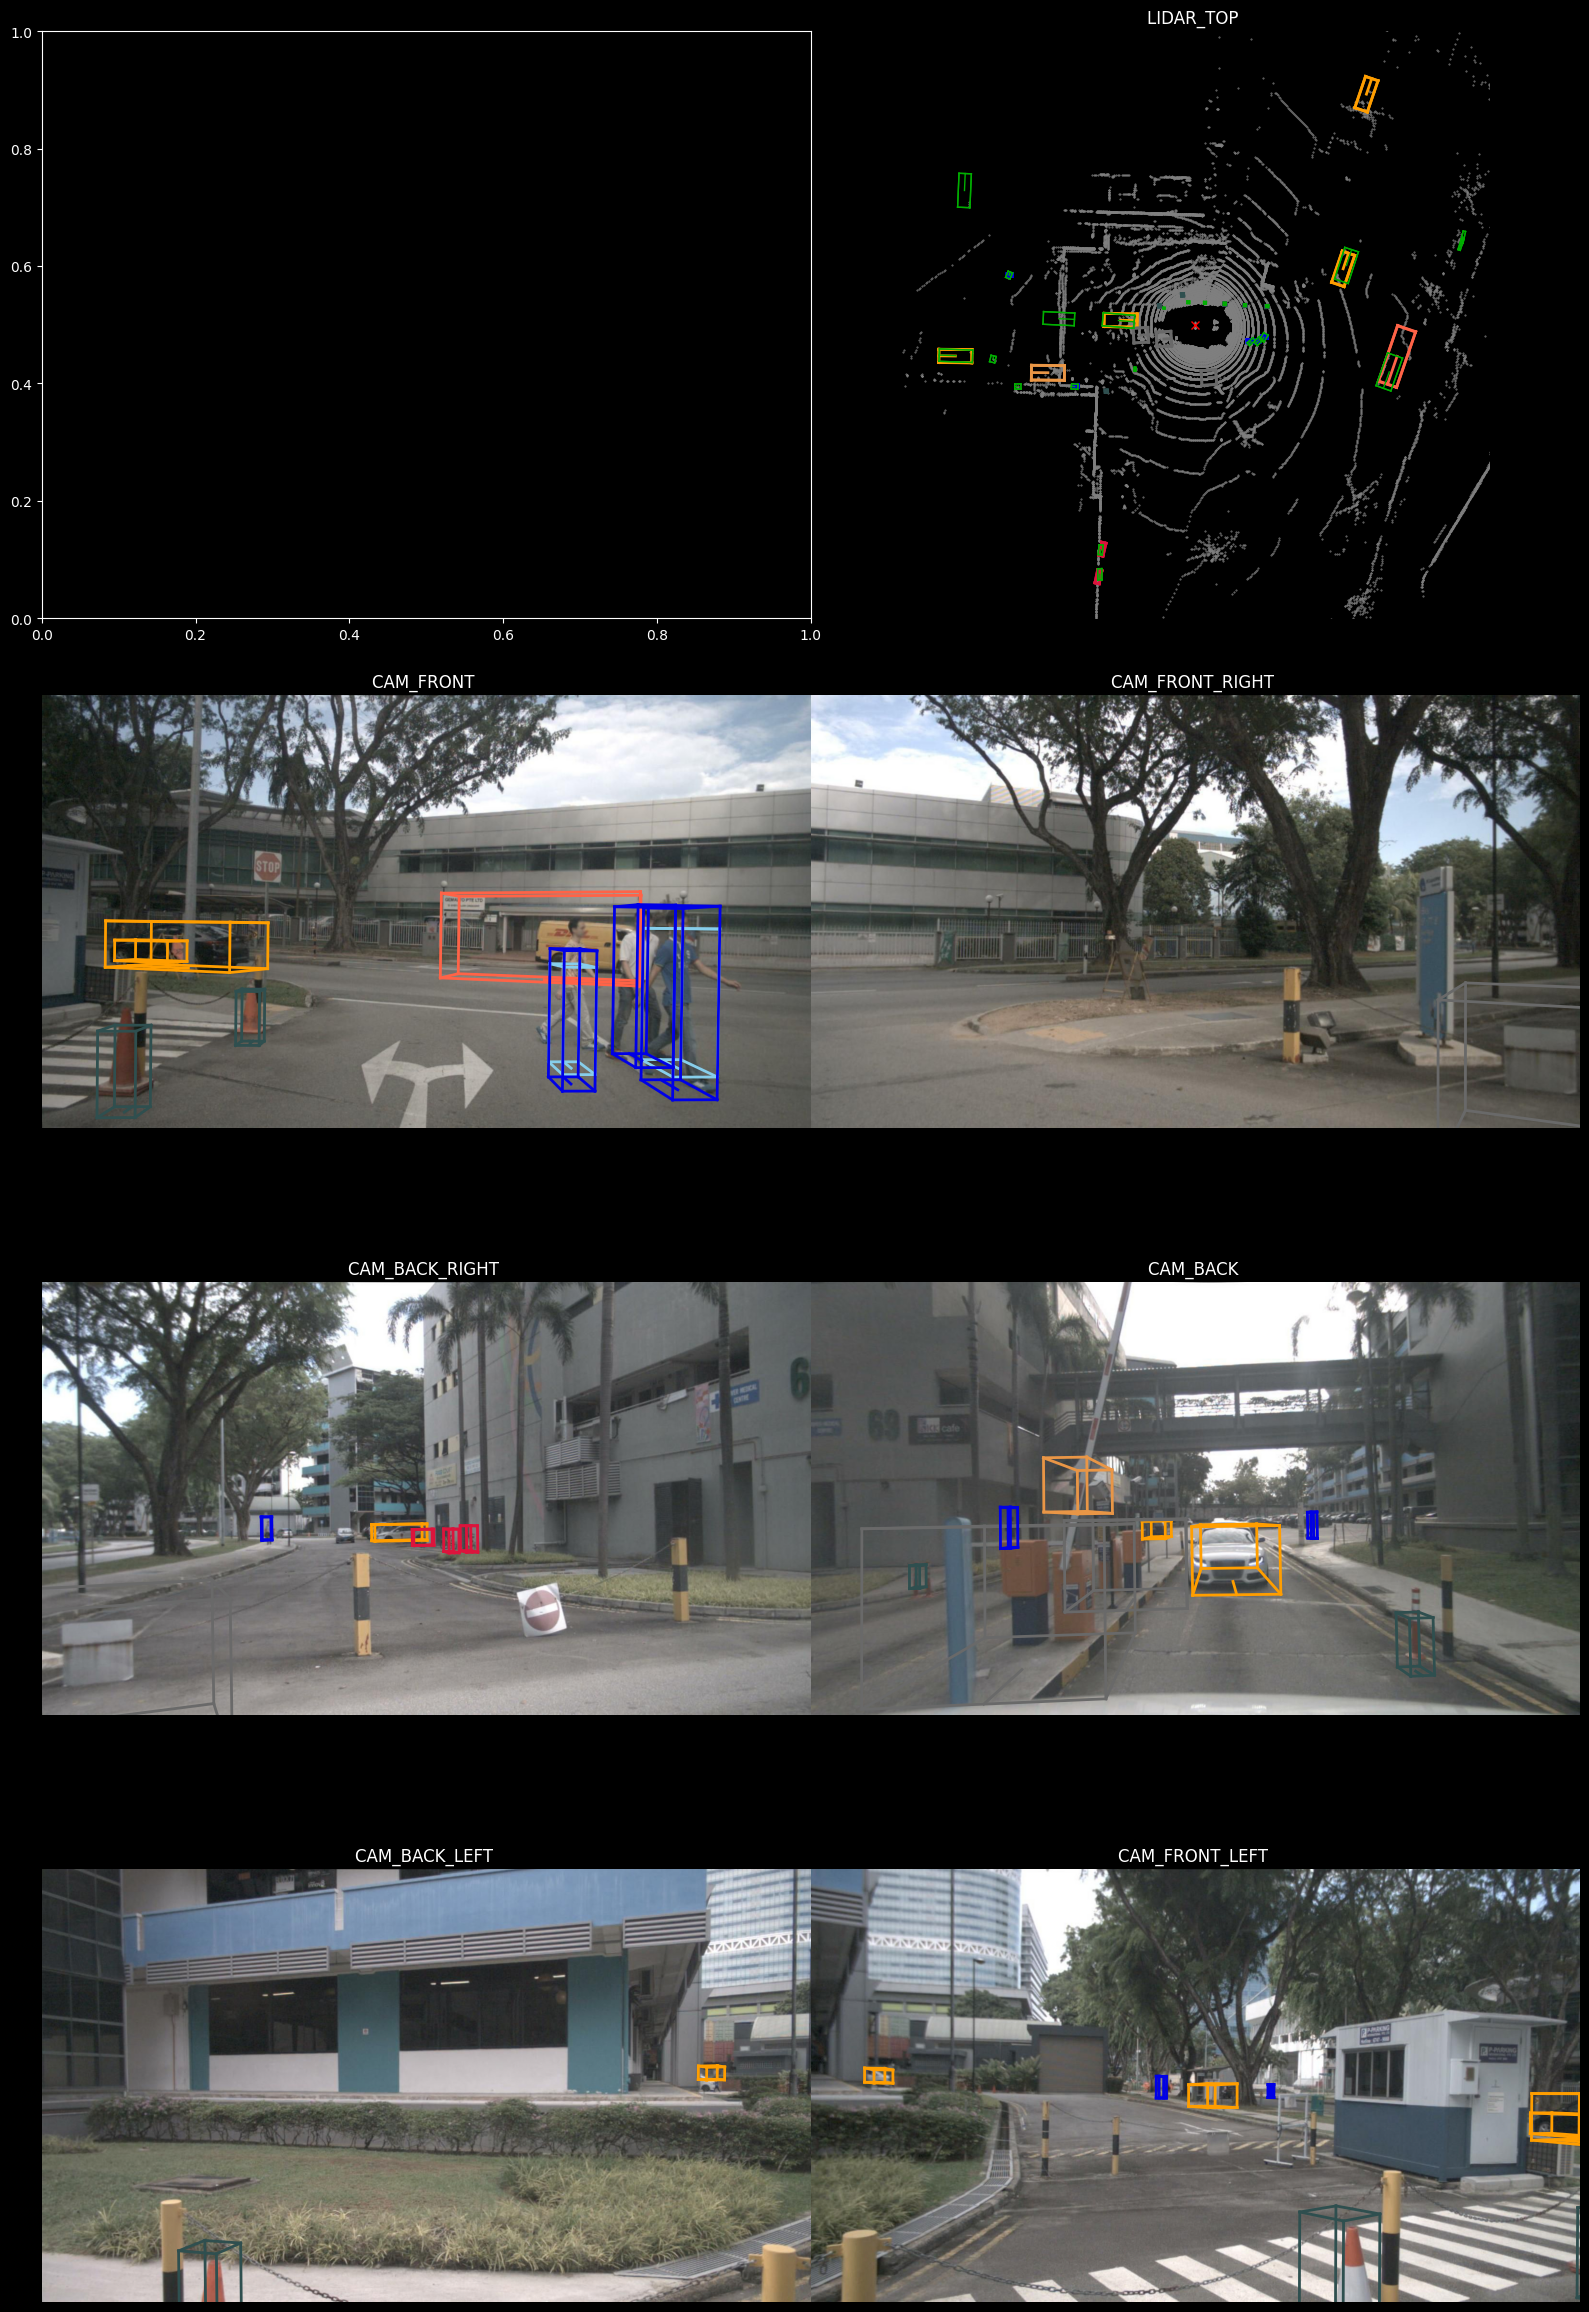

In [ ]:
import sys
import cv2
import os
import tqdm
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import Box as NuScenesBox
from nuscenes.utils.splits import val
from nuscenes.utils.color_map import get_colormap
from nuscenes.utils.geometry_utils import view_points, box_in_image, BoxVisibility, transform_matrix
from pyquaternion.quaternion import Quaternion
import pickle
import json
import pycocotools
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Image as IPImage
import numpy as np

# Define constants
VIEWS = ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
         'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT']

CUSTOM_VOCABULARY = ['car', 'truck', 'trailer', 'bus', 'construction_vehicle', 'bicycle', 'motorcycle', 'emergency_vehicle',
                    'adult', 'child', 'police_officer', 'construction_worker', 'stroller', 'personal_mobility',
                    'pushable_pullable', 'debris', 'traffic_cone', 'barrier']

def count_frames(nusc, sample):
    """Count number of frames in a scene"""
    frame_count = 1

    if sample["next"] != "":
        frame_count += 1
        sample_counter = nusc.get("sample", sample["next"])

        while sample_counter["next"] != "":
            frame_count += 1
            sample_counter = nusc.get("sample", sample_counter["next"])

    return frame_count

def load_2d_detections(gd_path):
    """Load 2D detection results"""
    with open(gd_path, "r") as f:
        results_GD = json.load(f)
    
    results_GD_new = dict()
    for result_GD in results_GD:
        file_name = result_GD['file_name']
        x1, y1, w, h = result_GD['bbox']
        x2, y2 = x1 + w, y1 + h    
        
        if file_name in results_GD_new:
            results_GD_new[file_name]['boxes_filt_list'].append([x1, y1, x2, y2])
            results_GD_new[file_name]['labels_list'].append([result_GD['category_id']-1])
            results_GD_new[file_name]['scores_list'].append([result_GD['score']])
        else:
            results_GD_new[file_name] = dict()
            results_GD_new[file_name]['boxes_filt_list'] = list()
            results_GD_new[file_name]['labels_list'] = list()
            results_GD_new[file_name]['scores_list'] = list()
            results_GD_new[file_name]['boxes_filt_list'].append([x1, y1, x2, y2])
            results_GD_new[file_name]['labels_list'].append([result_GD['category_id']-1])
            results_GD_new[file_name]['scores_list'].append([result_GD['score']])            
    
    return results_GD_new

def load_info_dict(nuscenes_root):
    """Load information dictionary"""
    info_path = nuscenes_root + '/nuscenes_infos_val.pkl'
    info_data = pickle.load(open(info_path, 'rb'))
    info_data = list(sorted(info_data['infos'], key=lambda e: e['timestamp']))
    
    info_dict = {}
    for frame_num, info in enumerate(info_data):
        if info['token'] not in info_dict:
            info_dict[info['token']] = {}
            info_dict[info['token']].update({
                'lidar2ego_translation': info['lidar2ego_translation'],
                'lidar2ego_rotation': info['lidar2ego_rotation'],
                'ego2global_translation': info['ego2global_translation'],
                'ego2global_rotation': info['ego2global_rotation'],
                'lidar_path': info['lidar_path'],
                'cams': info['cams']
            })
    
    return info_dict

def process_2d_detections(args, nusc, sample, results_GD_new, sample_token, sample_count):
    """Process 2D detection results"""
    for view in args['views']:
        if view not in VIEWS:
            print(f"Warning: View {view} is not in supported views list, skipping")
            continue
            
        try:
            (path, nusc_boxes, camera_instrinsic) = nusc.get_sample_data(sample["data"][view])
        except KeyError:
            print(f"Warning: No data for view {view} in sample {sample_token}, skipping")
            continue

        # Get 2D detection results
        file_name = path.split('/')[-1]
        if file_name in results_GD_new and args['use_gd']:
            image_pil = Image.open(path).convert('RGB')
            image = np.array(image_pil)
            image = image[:, :, ::-1].copy()  
            boxes_filt_list = results_GD_new[file_name]['boxes_filt_list']
            labels_list = results_GD_new[file_name]['labels_list']
            scores_list = results_GD_new[file_name]['scores_list']
    
            # Draw 2D detection boxes
            for i, box in enumerate(boxes_filt_list):
                min_col, min_row, max_col, max_row = box
                label = labels_list[i][0]
                category_name = CUSTOM_VOCABULARY[label]
                score = scores_list[i][0]
                if score < args['score_threshold']:
                    continue
                colors = nusc.colormap[category_name]
                # RGB -> BGR
                colors = (colors[2], colors[1], colors[0])
                cv2.rectangle(image, (int(min_col), int(min_row)), (int(max_col), int(max_row)), colors, 3) 
            
            # Save 2D detection results
            if sample_count % args['save_interval'] == 0:
                os.makedirs(f"{args['save_dir']}/2D_detections/{view}", exist_ok=True)
                save_path = f"{args['save_dir']}/2D_detections/{view}/{sample_token}&{view}_2D.jpg"
                cv2.imwrite(save_path, image)
    
    return

def process_3d_detections(args, nusc, sample_token, info_dict, sample_count):
    """Process 3D detection results"""
    # Load 3D detection results
    res3d = json.load(open(args['res3d_path'], 'r'))
    
    if sample_token not in res3d['results']:
        print(f"Warning: No 3D detection results for sample {sample_token}")
        return
    
    pred_res = res3d['results'][sample_token]
    box_dict = {'EGO': []}
    for view in VIEWS:
        box_dict[view] = []
    box_list = []
    
    for res in pred_res:
        score = res['detection_score']
        if score < args['score_threshold']:
            continue
            
        pred_box_nusc = NuScenesBox(
            res['translation'],
            res['size'],
            Quaternion(res['rotation']),
            name=res['detection_name'],
            score=res['detection_score'],
            velocity=(0, 0, 0))
        
        # Transform to ego-pose coordinate system
        pred_box_nusc.translate(-np.array(info_dict[sample_token]['ego2global_translation']))
        pred_box_nusc.rotate(Quaternion(info_dict[sample_token]['ego2global_rotation']).inverse)
        box_dict['EGO'].append(pred_box_nusc)
        
        for view in VIEWS:
            pred_box_nusc_camera = pred_box_nusc.copy()
            pred_box_nusc_camera.translate(-np.array(info_dict[sample_token]['cams'][view]['sensor2ego_translation']))
            pred_box_nusc_camera.rotate(Quaternion(info_dict[sample_token]['cams'][view]['sensor2ego_rotation']).inverse)
            box_dict[view].append(pred_box_nusc_camera)
                        
        box_list.append(pred_box_nusc)
    
    # Save 3D detection results
    if sample_count % args['save_interval'] == 0:
        os.makedirs(f"{args['save_dir']}/3D_only_lidar_detections", exist_ok=True)
        os.makedirs(f"{args['save_dir']}/3D_detections", exist_ok=True)
        
        # Show only lidar detection results
        # out_path = f"{args['save_dir']}/3D_only_lidar_detections/{sample_token}_lidar.png"
        # nusc.render_sample(True, False, sample_token, box_vis_level=BoxVisibility.ALL, 
        #                   out_path=out_path, box_list=box_list, box_dict=box_dict)
        
        # Show complete 3D detection results
        out_path = f"{args['save_dir']}/3D_detections/{sample_token}.png"                
        nusc.render_sample(False, True, sample_token, box_vis_level=BoxVisibility.ALL, 
                          out_path=out_path, box_list=box_list, box_dict=box_dict)

def main():
    """Main function"""
    # Set default parameter values
    args = {
        'sample_token': None,
        'score_threshold': 0.3,
        'save_interval': 35,
        'views': ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
                 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'],
        'save_dir': 'outputs/nuscenes/results_3D/visualiztions/',
        'gd_path': 'data/nuscenes/outputs/result_2D_0_seq_0.1.bbox.json',
        'res3d_path': 'outputs/nuscenes/results_3D/result_3D_0_seq_sorted.json',
        'nuscenes_root': 'data/nuscenes/',
        'version': 'v1.0-trainval',
        'use_gd': True
    }
    
    print("[INFO] Running with parameters:")
    for k, v in args.items():
        print(f"  {k}: {v}")
    
    # Print process ID
    getpid_X = os.getpid()
    print(f"Process ID: {getpid_X}")
    
    # Initialize NuScenes dataset
    nusc = NuScenes(version=args['version'], dataroot=args['nuscenes_root'], verbose=True)
    
    # Load info
    info_dict = load_info_dict(args['nuscenes_root'])
    
    # Load 2D detection results
    if args['use_gd']:
        results_GD_new = load_2d_detections(args['gd_path'])
    else:
        results_GD_new = {}
    
    
    # Process all validation set scenes
    sample_count = 1
    for scene_num, scene_name in enumerate(val):
        if scene_num > 0:
            break
        scene_token = nusc.field2token("scene", "name", scene_name)[0]
        scene = nusc.get("scene", scene_token)
        sample = nusc.get("sample", scene["first_sample_token"])         
        num_frames = count_frames(nusc, sample)

        for f in range(num_frames):
            sample_token = sample["token"]
            
            # Process 2D detections
            # process_2d_detections(args, nusc, sample, results_GD_new, sample_token, sample_count)
        
            # Process 3D detections
            process_3d_detections(args, nusc, sample_token, info_dict, sample_count)

            if sample['next'] != "":
                sample = nusc.get('sample', sample['next'])
                sample_count += 1
            else:
                break

if __name__ == '__main__':
    main()
    